# Laboratorio 2: Armado de un esquema de aprendizaje automático

En el laboratorio final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`. Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

In [1]:
import numpy as np
import pandas as pd

# TODO: Agregar las librerías que hagan falta
from sklearn.model_selection import train_test_split

## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [2]:
#dataset = pd.read_csv("./data/loan_data.csv", comment="#")
dataset = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")


# División entre instancias y etiquetas
X, y = dataset.iloc[:, 1:], dataset.TARGET

# división entre entrenamiento y evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


Documentación:

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponible para hacer la predicción?
4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?

**No hace falta escribir código para responder estas preguntas.**

In [3]:
dataset.head(5)

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106


1. ¿De qué se trata el conjunto de datos? <br>
El conjunto de datos parece contener información crediticia de solicitantes de préstamos (loans). Cada fila representa a una persona o solicitud de préstamo, con distintas variables financieras y demográficas que describen su situación.

2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?<br>
En principio, lo que hay que determinar mediante las variables financieras es  el riesgo de brindar el prestamo al solicitante.
Esto en el dataset se presenta como la columna TARGET.<br>
TARGET parece indicar si el solicitante es riesgoso (1) o no riesgoso (0). Es decir, es un problema de clasificación binaria.

3. ¿Qué información (atributos) hay disponible para hacer la predicción?<br>
Los atributos disponibles son:

    - **LOAN**: Monto del préstamo solicitado.

    - **MORTDUE**: Monto adeudado de la hipoteca.

    - **VALUE**: Valor de la propiedad.

    - **YOJ**: Años en el trabajo actual.

    - **DEROG**: Número de reportes negativos de crédito mayores.

    - **DELINQ**: Número de líneas de crédito con pagos atrasados.

    - **CLAGE**: Antigüedad promedio de las líneas de crédito (en meses o años).

    - **NINQ**: Número de consultas recientes de crédito.

    - **CLNO**: Número de líneas de crédito abiertas.

    - **DEBTINC**: Relación deuda-ingreso.

Estos atributos brindan información sobre la situación financiera, historial de crédito y nivel de endeudamiento del solicitante.

4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?<br>
Intuitivamente, los atributos que podrían tener mayor impacto son:

    - **DEROG y DELINQ**: reflejan la confiabilidad del historial de crédito.

    - **DEBTINC**: muestra qué proporción de sus ingresos se destina a pagar deudas. Cuanto más alta, mayor riesgo.

    - **CLAGE**: la antigüedad del historial crediticio puede influir (un historial largo y sin problemas suele ser mejor).

    - **NINQ**: muchas consultas recientes pueden indicar necesidad urgente de crédito (potencial señal de riesgo).

    - **LOAN, MORTDUE y VALUE**: pueden ser relevantes para analizar la relación entre deuda y avalúo de la propiedad.

## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

In [4]:
# Librerías necesarias
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Establecemos un pipeline que realiza dos procesos a los datos:
1. Una estandarización de los datos (todos los datos son numéricos).
2. Un clasificador de los datos.

In [5]:
pipeline = make_pipeline(
    StandardScaler(), # Escala cada variable numérica para que tenga media 0 y desviación estándar 1
    SGDClassifier(random_state=0) #Implementa un estimador lineal entrenado con Gradiente Descendente Estocástico (SGD).
)

Es importante entender que ahora aplicaremos el pipeline anterior por separado a las particiones de entrenamiento, test y validación (si existiese).  
El motivo de hacer esto es que, si hubiéramos realizado una estandarización de todo el dataset al mismo tiempo, la estaríamos calculando teniendo en cuenta tanto los datos de entrenamiento como los de test.  
Esto sería una filtración de datos (*data leakage*) de los datos de test hacia los datos de entrenamiento, lo que generaría algún tipo de sesgo.

Ahora el pipeline hereda las funcionalidades del clasificador (es un wrapper), por lo cual podemos pedirle que entrene y que realice las predicciones.

In [6]:
# Ejecutamos el pipeline sobre los datos de entrenamiento
pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdclassifier', SGDClassifier(random_state=0))])

In [7]:
# Hacemos predicciones sobre los datos de entrenamiento y test
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def print_metrics(y_true, y_pred, dataset_name):
    print(f"=== Métricas para {dataset_name} ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Real Negativo', 'Real Positivo'],
        columns=['Predicho Negativo', 'Predicho Positivo']
    )

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusión - {dataset_name}")
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()
    print("-"*40)


=== Métricas para Entrenamiento ===
Accuracy : 0.8732
Precision: 0.7143
Recall   : 0.4183
F1 Score : 0.5276


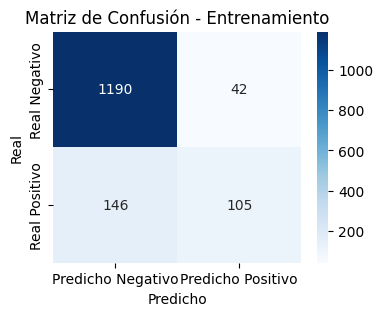

----------------------------------------
=== Métricas para Evaluación ===
Accuracy : 0.8679
Precision: 0.6452
Recall   : 0.3448
F1 Score : 0.4494


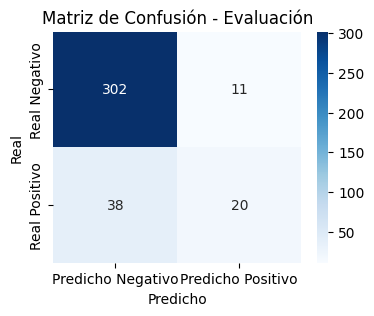

----------------------------------------


In [9]:
print_metrics(y_train, y_pred_train, "Entrenamiento")
print_metrics(y_test, y_pred_test, "Evaluación")


**Accuracy:**<br>
El accuracy es bastante alto y consistente entre el entrenamiento y el test. Esto sugiere que el modelo no tiene overfitting excesivo. Si esto fuera así, el accuracy del entrenamiento daría muy alto y el del test daría muy bajo.

**Precision:**  
Cuando el modelo predice que el target es positivo, acierta aproximadamente un 71% de las veces en entrenamiento y un 65% en test. Esto indica que es un modelo relativamente conservador, ya que minimiza la cantidad de falsos positivos a costa de posiblemente dejar pasar verdaderos positivos.


**Recall**<br>

De todos los casos realmente positivos, el mmodelo solo encuentra el 41% en entrenamiento y 34% en test.<br> Es decir, está dejando pasar bastantes casos positivos (falsos negativos).

**F1 Score:** <br>
Este parámetro combina precisión y recall en un solo número. Prefiero analizar estos parámetros por separado.  

**Matriz de Confusión:**<br>
Entrenamiento
- 1190 TN: Verdaderos negativos que fueron bien clasificados como negativos.
- 42 FP: Falsos positivos que fueron mal clasificados como positivos.
- 146 FN: Falsos negativos que en realidad eran positivos.
- 105 TP: Verdaderos positivos clasificados correctamente.

Test
- 302 TN: Verdaderos negativos que fueron bien clasificados como negativos.
- 11 FP: Falsos positivos que fueron mal clasificados como positivos.
- 38 FN: Falsos negativos que en realidad eran positivos.
- 20 TP: Verdaderos positivos clasificados correctamente.

Se clasifica bien la clase negativa y tiene alta precisión para positivos, pero el recall es bajo, así que no detecta todos los casos positivos.

Esto es de esperar dado que ni siquiera se han ajustados los hiperparámetros aún.

### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
# Hiperparámetros con los que se hará un grid search
param_grid = {
    'sgdclassifier__loss': ['hinge', 'log_loss', 'modified_huber'], # Prueba diferentes funciones de loss
    'sgdclassifier__alpha': [0.0001, 0.001, 0.01], # Diferentes penalizaciones a los pesos
    'sgdclassifier__eta0': [0.01, 0.1, 1.0], # Diferentes learning rate
    'sgdclassifier__learning_rate': ['constant'] # Para dejar fijas las tazas de aprendizaje eta0 en cada prueba
}

Con esto estamos probando `3 x 3 x 3 x 1 = 27` combinaciones de hiperparámetros.

In [12]:
# Utilizaremos Cross-Validation para obtener la mejor combinación
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # Cross-validation con 5 folds
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

Al establecerle `cv = 5` estamos haciendo que para buscar la mejor combinación de hiperparámetros, GridSearchCV divida el conjunto de entrenamiento en 5 partes (*folds*) de aproximadamente el mismo tamaño.

De estas 5 partes, toma 4 para entrenar y una para validar. Esto se repite 5 veces y va cambiando cual es el fold de validación.

El parámetro que utiliza para ver cual es la mejor combinación es el Accuracy.

Esto quiere decir, que si son 27 las combinaciones de hiperparámetros, y son 5 las combinaciones de folds, la cantida de entrenamientos totales será de `27 x 5 = 135`.

In [13]:
# Ejecutamos los múltiples entrenamientos
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('sgdclassifier',
                                        SGDClassifier(random_state=0))]),
             n_jobs=-1,
             param_grid={'sgdclassifier__alpha': [0.0001, 0.001, 0.01],
                         'sgdclassifier__eta0': [0.01, 0.1, 1.0],
                         'sgdclassifier__learning_rate': ['constant'],
                         'sgdclassifier__loss': ['hinge', 'log_loss',
                                                 'modified_huber']},
             return_train_score=True, scoring='accuracy')

In [14]:
# Adjuntamos los resultados
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['params', 'mean_test_score', 'std_test_score']]
cv_results = cv_results.sort_values(by='mean_test_score', ascending=False)

In [15]:
# Imprimimos los mejores 5
cv_results.head(5)

,params,mean_test_score,std_test_score
0,"{'sgdclassifier__alpha': 0.0001, 'sgdclassifie...",0.871886,0.007005
1,"{'sgdclassifier__alpha': 0.0001, 'sgdclassifie...",0.870539,0.011747
10,"{'sgdclassifier__alpha': 0.001, 'sgdclassifier...",0.869865,0.011737
19,"{'sgdclassifier__alpha': 0.01, 'sgdclassifier_...",0.869183,0.009177
9,"{'sgdclassifier__alpha': 0.001, 'sgdclassifier...",0.868512,0.004712


In [16]:
print("\nMejores hiperparámetros encontrados:\n")
print(grid_search.best_params_)
print(f"\nMejor accuracy promedio: {grid_search.best_score_:.4f}")


Mejores hiperparámetros encontrados:

{'sgdclassifier__alpha': 0.0001, 'sgdclassifier__eta0': 0.01, 'sgdclassifier__learning_rate': 'constant', 'sgdclassifier__loss': 'hinge'}

Mejor accuracy promedio: 0.8719


In [17]:
# Evaluamos la mejor configuración
best_model = grid_search.best_estimator_

In [18]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

=== Métricas para Entrenamiento ===
Accuracy : 0.8719
Precision: 0.8765
Recall   : 0.2829
F1 Score : 0.4277


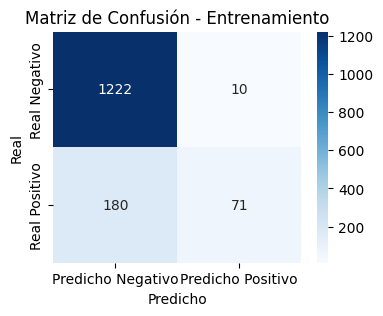

----------------------------------------
=== Métricas para Evaluación ===
Accuracy : 0.8841
Precision: 0.9412
Recall   : 0.2759
F1 Score : 0.4267


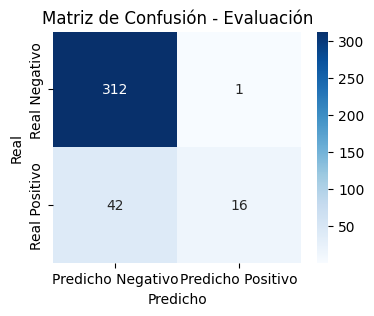

----------------------------------------


In [19]:
print_metrics(y_train, y_pred_train, "Entrenamiento")
print_metrics(y_test, y_pred_test, "Evaluación")


**Accuracy:**  
El accuracy sigue siendo bastante alto y consistente entre entrenamiento (87%) y test (84%).

**Precision:**  
Cuando el modelo predice que el target es positivo, acierta aproximadamente un 87% de las veces en entrenamiento y un 94% en test. Esto muestra que el modelo sigue siendo muy conservador.

**Recall:**  
De todos los casos realmente positivos, el modelo solo encuentra alrededor del 28% en entrenamiento y aproximadamente el 28% en test. Esto significa que todavía deja pasar bastantes casos positivos (falsos negativos).

**F1 Score:**  
El F1 Score combina precisión y recall en un solo número. Prefiero analizarlos por separado.

**Matriz de Confusión:**  
**Entrenamiento**
- 1222 TN: Verdaderos negativos bien clasificados como negativos.
- 10 FP: Falsos positivos mal clasificados como positivos.
- 180 FN: Falsos negativos que en realidad eran positivos.
- 71 TP: Verdaderos positivos clasificados correctamente.

**Test**
- 312 TN: Verdaderos negativos bien clasificados como negativos.
- 1 FP: Falso positivo mal clasificado como positivo.
- 42 FN: Falsos negativos que en realidad eran positivos.
- 16 TP: Verdaderos positivos clasificados correctamente.

Se sigue clasificando muy bien la clase negativa y la precisión para positivos es aún más alta que antes, pero el recall sigue siendo bajo, así que el modelo continúa sin detectar todos los casos positivos.

Estos resultados muestran cómo el ajuste de hiperparámetros permitió mejorar el accuracy, pero la mejora es bastante limitada.

## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Los arboles de decisión no necesitan escalar los datos numéricos, por lo cual no hace falta normalizarlos. Entonces no realizaremos un Pipeline.

In [20]:
from sklearn.tree import DecisionTreeClassifier

# Creo el árbol
tree_clf = DecisionTreeClassifier(random_state=0)


In [21]:
# Entreno el árbol
tree_clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=0)

In [22]:
# Evaluo el modelo entrenado
y_pred_train = tree_clf.predict(X_train)
y_pred_test = tree_clf.predict(X_test)


=== Métricas para Entrenamiento ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


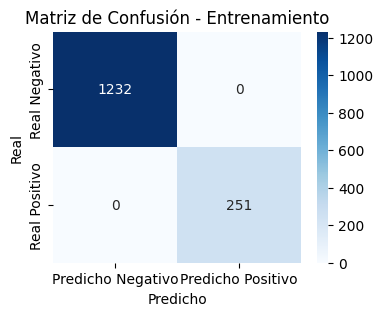

----------------------------------------
=== Métricas para Evaluación ===
Accuracy : 0.8814
Precision: 0.6167
Recall   : 0.6379
F1 Score : 0.6271


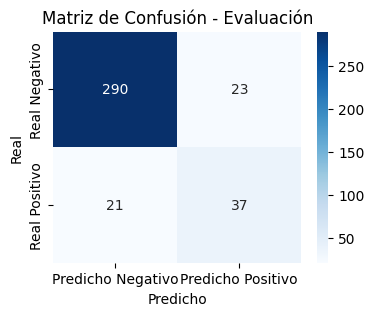

----------------------------------------


In [23]:
print_metrics(y_train, y_pred_train, "Entrenamiento")
print_metrics(y_test, y_pred_test, "Evaluación")


Solo miremos el Accuracy.

**Accuracy:**  
El accuracy es extremadamente alto en entrenamiento (100%) y más bajo en test (81%). Esto muestra claramente que el árbol se ha sobreajustado a los datos de entrenamiento.

Sabiendo que existe overfitting pasemos directamente a mejorar el entrenamiento con un ajuste en los hiperparámetros, en especial con los parámetros `max_depth` o `min_samples_leaf`.


### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [24]:
# Genero de nuevo el árbol base
tree_clf = DecisionTreeClassifier(random_state=0)

In [25]:
# Establezco algunos hiperparámetros con los cuales probar
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}


In [26]:
# Utilizaremos nuevamente CrossValidation
grid_search = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)


In [27]:
# Realizo los múltiples entrenamientos
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 5, 10]},
             return_train_score=True, scoring='accuracy')

In [28]:
# Adjuntamos los resultados
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['params', 'mean_test_score', 'std_test_score']]
cv_results = cv_results.sort_values(by='mean_test_score', ascending=False)


In [29]:
# Imprimimos los mejores 5
cv_results.head(5)

,params,mean_test_score,std_test_score
15,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.883354,0.013152
17,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.882678,0.021342
18,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.880669,0.020292
31,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.880647,0.003456
35,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.879971,0.006968


In [30]:
print("\nMejores hiperparámetros encontrados:\n")
print(grid_search.best_params_)
print(f"\nMejor accuracy promedio: {grid_search.best_score_:.4f}")



Mejores hiperparámetros encontrados:

{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10}

Mejor accuracy promedio: 0.8834


=== Métricas para Entrenamiento ===
Accuracy : 0.8975
Precision: 0.9024
Recall   : 0.4422
F1 Score : 0.5936


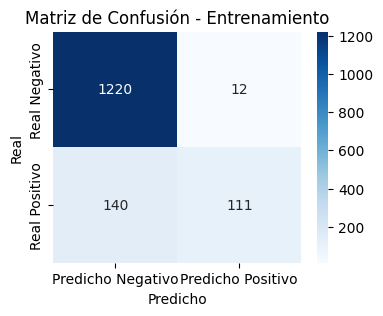

----------------------------------------
=== Métricas para Evaluación ===
Accuracy : 0.8922
Precision: 0.8000
Recall   : 0.4138
F1 Score : 0.5455


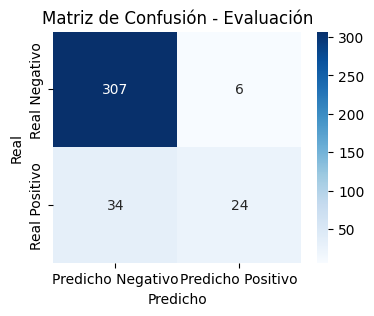

----------------------------------------


In [31]:
# Mejor modelo
best_tree = grid_search.best_estimator_

# Predicciones
y_pred_train = best_tree.predict(X_train)
y_pred_test = best_tree.predict(X_test)

print_metrics(y_train, y_pred_train, "Entrenamiento")
print_metrics(y_test, y_pred_test, "Evaluación")


**Accuracy:**  
El accuracy ahora es de 89.7% en entrenamiento y 80.2% en test. Esta reducción en el accuracy de entrenamiento es esperable porque el árbol ahora está limitado (poda). El hecho de que la diferencia entre entrenamiento y test sea mucho menor muestra que se redujo el **overfitting**, mejorando la capacidad de generalización.

**Precision:**  
El árbol acierta alrededor del 40% en entrenamiento y 38% en test cuando predice positivos. Esto muestra un modelo más equilibrado, que ya no memoriza casos individuales.

**Recall:**  
Detecta cerca del 44% en entrenamiento y 41% en test, capturando una parte razonable de los casos positivos sin sobreajustar.

**F1 Score:**  
Combina precisión y recall: es 0.59 en entrenamiento y 0.54 en test, reflejando un mejor equilibrio respecto al árbol sin podar.


**Matriz de Confusión:**  
**Entrenamiento**
- 1220 TN: Verdaderos negativos bien clasificados.
- 12 FP: Falsos positivos.
- 140 FN: Falsos negativos.
- 111 TP: Verdaderos positivos.

**Test**
- 307 TN: Verdaderos negativos bien clasificados.
- 6 FP: Falsos positivos.
- 34 FN: Falsos negativos.
- 24 TP: Verdaderos positivos.

El árbol ajustado clasifica bien la clase negativa y muestra un equilibrio más razonable entre precisión y recall para la clase positiva. La poda redujo el overfitting y mejoró la generalización en comparación con el árbol totalmente desarrollado.


---


